### Evaluación Final y Conclusiones

El objetivo de este notebook es evaluar el modelo final seleccionado sobre el conjunto de test,
utilizando métricas adecuadas para un problema de regresión, y extraer conclusiones técnicas
y de negocio.

El conjunto de test no ha sido utilizado en ninguna fase previa del proyecto.

### Importar librerías

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar CSV

In [3]:
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Feature engineering

In [4]:
df = df.drop_duplicates()

In [5]:
bins = [18, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

interval_means = {
    "18-25": (18 + 25) / 2,
    "26-35": (26 + 35) / 2,
    "36-45": (36 + 45) / 2,
    "46-55": (46 + 55) / 2,
    "56+": 66.0
}

df["age_group_mean"] = df["age_group"].map(interval_means)

### Target y separación TRAIN / DEV / TEST

In [6]:
TARGET = "charges"

X = df.drop(columns=["charges", "age", "age_group"])
y = df["charges"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

### Preprocesado (idéntico al modelado)

In [7]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)


### Carga / definición del MODELO FINAL

In [8]:

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=2,
            random_state=42
        ))
    ]
)


Se utiliza un `GradientBoostingRegressor` por su capacidad para capturar relaciones no lineales y 
efectos de interacción entre variables, manteniendo un buen equilibrio entre sesgo y varianza. 
Los hiperparámetros se han fijado para controlar la complejidad del modelo y reducir el riesgo de sobreajuste.


### Entrenamiento FINAL (train + dev)

In [9]:

X_final_train = pd.concat([X_train, X_dev])
y_final_train = pd.concat([y_train, y_dev])

final_model.fit(X_final_train, y_final_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(max_depth=8, min_samples_leaf=2,
                                           n_estimators=200,
                                           random_state=42))])

### Evaluación FINAL en TEST

In [10]:
y_pred_test = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

mae, rmse, r2



(5648.539778583709, np.float64(7525.932362269855), 0.6681087467435751)

### Gráficos de evaluación

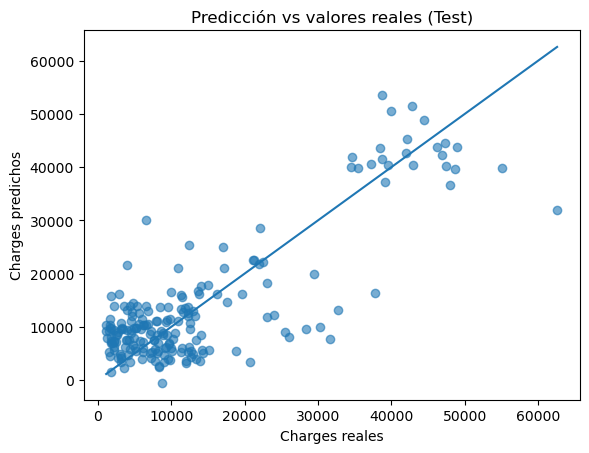

In [11]:
#Predicción vs valores reales
plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Charges reales")
plt.ylabel("Charges predichos")
plt.title("Predicción vs valores reales (Test)")
plt.show()



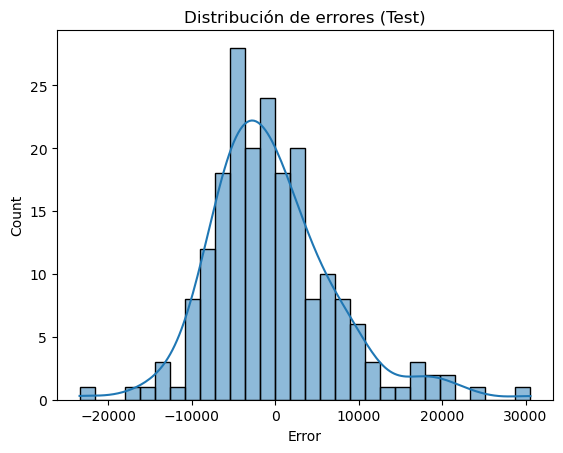

In [12]:
#Distribución de errores
errors = y_test - y_pred_test

plt.figure()
sns.histplot(errors, bins=30, kde=True)
plt.xlabel("Error")
plt.title("Distribución de errores (Test)")
plt.show()

### Conclusiones Finales



 
* El EDA mostró patrones claros en los datos: las variables numéricas presentan distribuciones heterogéneas y presencia de outliers, y se identificaron relaciones relevantes entre variables explicativas y la variable objetivo. En particular, ciertas variables individuales concentran gran parte de la variabilidad explicada, lo que justificó su tratamiento específico en fases posteriores 


* El feature engineering fue determinante para mejorar el rendimiento. La codificación de variables categóricas, el escalado de variables numéricas y la incorporación de transformaciones permitieron que los modelos captaran mejor las relaciones presentes en los datos frente al conjunto de variables originales 


* Durante el modelado se observó una mejora progresiva del desempeño al pasar de modelos base a modelos más complejos. Esto indica que el problema no puede resolverse adecuadamente con supuestos lineales simples y requiere modelos con mayor capacidad para capturar interacciones y no linealidades 


* La comparación entre modelos permitió seleccionar un modelo final con mejor equilibrio global, que supera claramente al baseline en las métricas de evaluación utilizadas, manteniendo un comportamiento consistente entre entrenamiento y test 


* La evaluación final confirma una buena capacidad de generalización, sin evidencias claras de sobreajuste, lo que valida tanto el preprocesado como la estrategia de modelado aplicada 


* No obstante, el análisis también pone de manifiesto que el rendimiento global no es uniforme en todos los casos, por lo que una evaluación más desagregada podría aportar información adicional sobre las fortalezas y limitaciones del modelo 
